1. *Data Inspection*

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [148]:
# Set display option
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Load the dataset
df_raw = pd.read_csv("../data/raw/sapacr-2008-2023-v1.1.csv", encoding='latin1')
df_raw.head(5)

,year,station,loc_mn,dc_mn,longitude,latitude,other_theft,arson,assault_gbh,attempted_murder,attempted_sexoff,bank_robbery,burglary_nonres,burglary_res,carjacking,commercial_crime,common_assault,common_robbery,contact_sexoff,dui,drug_crime,illegal_firearms,kidnapping,malicious_damage,murder,rape,robbery_nonres,robbery_res,cash_transit_robbery,aggr_robbery,sexual_assault,sexual_offences,police_detected_sexoff,shoplifting,stock_theft,vehicle_theft,theft_from_vehicle,truck_hijacking
0,2008/2009,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,491,3,570,25,3,0,104,226,25,161,443,132,1,213,113,34,1,236,24,58,34,42,1,293,7,119,0,218,0,143,272,0
1,2009/2010,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,452,5,625,9,3,0,86,180,35,154,473,127,2,264,283,22,1,252,14,55,27,57,1,276,13,115,0,185,0,124,300,0
2,2010/2011,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,525,1,586,15,5,0,83,231,23,247,469,113,3,228,108,10,1,208,21,60,36,27,0,238,23,101,0,164,0,96,256,0
3,2011/2012,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,559,2,591,18,5,0,92,199,54,197,437,103,4,340,161,18,1,210,10,42,54,46,0,328,3,52,1,111,0,104,243,0
4,2012/2013,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,562,0,556,29,5,0,73,210,48,129,441,134,5,351,155,28,1,262,17,71,51,56,1,355,17,96,3,133,0,136,380,0


In [138]:
print("Dataset loaded, Shape:", df_raw.shape)

Dataset loaded, Shape: (17265, 38)


2. *Data Auditing*

In [149]:
# 1. Basic info
print("===Basic Info===")
df_raw.info()

# 2. Missing values
print("\n=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'missing_count':missing, 'missing_pct':missing_pct})
print(missing_df[missing_df['missing_count']>0].sort_values('missing_pct', ascending=False))

# 3. Duplicates
print("\n===Duplicates===")
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

# 4. Unique value counts per column
print("\n===Unique Values===")
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")
    
# 5. Summary stats for numeric columns
print("\n===Summary Stats===")
df_raw.describe(include='all')

===Basic Info===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17265 entries, 0 to 17264
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    17265 non-null  object 
 1   station                 17265 non-null  object 
 2   loc_mn                  16980 non-null  object 
 3   dc_mn                   16980 non-null  object 
 4   longitude               16965 non-null  float64
 5   latitude                16965 non-null  float64
 6   other_theft             17265 non-null  int64  
 7   arson                   17265 non-null  int64  
 8   assault_gbh             17265 non-null  int64  
 9   attempted_murder        17265 non-null  int64  
 10  attempted_sexoff        17265 non-null  int64  
 11  bank_robbery            17265 non-null  int64  
 12  burglary_nonres         17265 non-null  int64  
 13  burglary_res            17265 non-null  int64  
 14  carjacking           

,year,station,loc_mn,dc_mn,longitude,latitude,other_theft,arson,assault_gbh,attempted_murder,attempted_sexoff,bank_robbery,burglary_nonres,burglary_res,carjacking,commercial_crime,common_assault,common_robbery,contact_sexoff,dui,drug_crime,illegal_firearms,kidnapping,malicious_damage,murder,rape,robbery_nonres,robbery_res,cash_transit_robbery,aggr_robbery,sexual_assault,sexual_offences,police_detected_sexoff,shoplifting,stock_theft,vehicle_theft,theft_from_vehicle,truck_hijacking
count,17265,17265,16980,16980,16965.000000,16965.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000,17265.000000
unique,15,1151,210,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2008/2009,yeoville,city of cape town,city of cape town,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1151,15,900,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,26.780270,-28.902783,281.022821,4.204807,154.610194,15.765943,2.344570,0.019288,60.807935,195.823458,12.877150,71.601564,147.810715,44.470837,7.326267,57.577353,175.447727,12.898407,12.120127,101.317000,16.650796,37.554474,15.642572,17.406777,0.170634,108.197567,5.993455,48.499855,4.366348,57.158529,23.389053,46.262323,104.482827,1.091978
std,NaN,NaN,NaN,NaN,3.839633,3.201970,441.488851,5.842701,172.151418,25.868634,3.310832,0.184014,80.312592,240.553229,30.249276,155.887962,209.809279,88.920979,5.875825,110.127136,353.702502,21.982118,12.476593,136.613499,26.130766,43.858709,23.381612,31.663089,0.598854,182.975461,8.173655,56.574735,34.477296,132.531411,32.246618,104.979312,223.672552,3.661221
min,NaN,NaN,NaN,NaN,16.492180,-34.800590,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,NaN,NaN,NaN,NaN,25.305790,-31.621870,34.000000,0.000000,38.000000,2.000000,0.000000,0.000000,11.000000,33.000000,0.000000,3.000000,23.000000,3.000000,6.000000,3.000000,15.000000,1.000000,1.000000,16.000000,2.000000,8.000000,1.000000,1.000000,0.000000,6.000000,1.000000,11.000000,0.000000,0.000000,2.000000,1.000000,4.000000,0.000000
50%,NaN,NaN,NaN,NaN,27.900260,-28.698080,112.000000,2.000000,95.000000,6.000000,1.000000,0.000000,34.000000,105.000000,1.000000,14.000000,70.000000,14.000000,6.000000,16.000000,58.000000,4.000000,13.000000,48.000000,7.000000,22.000000,6.000000,5.000000,0.000000,29.000000,3.000000,30.000000,0.000000,4.000000,12.000000,6.000000,21.000000,0.000000
75%,NaN,NaN,NaN,NaN,29.702660,-26.196550,339.000000,6.000000,210.000000,19.000000,3.000000,0.000000,79.000000,267.000000,9.000000,70.000000,187.000000,49.000000,7.000000,62.000000,179.000000,15.000000,16.000000,131.000000,20.000000,51.000000,21.000000,19.000000,0.000000,128.000000,8.000000,66.000000,0.000000,52.000000,32.000000,35.000000,98.000000,1.000000


3. *Data Cleaning & Preprocessing*

In [150]:
# make a copy to work on
df_clean = df_raw.copy()

# 1.Handle missing values
# For numeric columns, fill with median or mean, for categories, fill with mode
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(include='object').columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
    

for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0]if not df_clean[col].mode().empty else "unknown", inplace=True)
                         
# 2. Remove duplicates if any
df_clean.drop_duplicates(inplace=True)                      

# 3. Standardize categorical columns (lowercase, trim)
for col in cat_cols:
    if df_clean[col].dtype == 'object':
       df_clean[col] = df_clean[col].str.lower().str.strip()
    
# create crime_category column and combine similar crimes into appropriate category
crime_mapping = {
    # Contact Crimes
    'murder': 'contact_crime',
    'attempted_murder': 'contact_crime',
    'assault_gbh': 'contact_crime',
    'common_assault': 'contact_crime',
    'rape': 'contact_crime',
    'sexual_assault': 'contact_crime',

    # Contact-Related
    'arson': 'contact_related',
    'malicious_damage': 'contact_related',

    # Property Crimes
    'burglary_res': 'property_crime',
    'burglary_nonres': 'property_crime',
    'vehicle_theft': 'property_crime',
    'theft_from_vehicle': 'property_crime',
    'shoplifting': 'property_crime',
    'stock_theft': 'property_crime',
    'other_theft': 'property_crime',

    # Robbery
    'common_robbery': 'robbery',
    'aggr_robbery': 'robbery',
    'carjacking': 'robbery',
    'truck_hijacking': 'robbery',
    'robbery_res': 'robbery',
    'robbery_nonres': 'robbery',
    'cash_transit_robbery': 'robbery',
    'bank_robbery': 'robbery',

    # Crime Detected
    'drug_crime': 'crime_detected',
    'dui': 'crime_detected',
    'illegal_firearms': 'crime_detected',

    # Other Serious
    'kidnapping': 'other_serious',
    'commercial_crime': 'other_serious',

    # Sexual Offences
    'contact_sexoff': 'sexual_offences',
    'sexual_offences': 'sexual_offences',
    'attempted_sexoff': 'sexual_offences',
    'police_detected_sexoff': 'sexual_offences'
}

# Create grouped dataframe
df_grouped = df_clean.copy()

# Create new grouped columns
for group in set(crime_mapping.values()):
    cols = [col for col in crime_mapping if col in df_grouped.columns and crime_mapping[col] == group]
    df_grouped[group] = df_grouped[cols].sum(axis=1)
    
# Extract start year
df_grouped['year_start'] = df_grouped['year'].str.split('/').str[0]

# Convert to datetime
df_grouped['year_start'] = pd.to_datetime(df_grouped['year_start'], format='%Y')

# Define grouped columns
group_cols = [
    'contact_crime',
    'contact_related',
    'property_crime',
    'robbery',
    'crime_detected',
    'other_serious'
]

# 1. Total cases
df_grouped['total_cases'] = df_grouped[group_cols].sum(axis=1)

# 2. Get dominant crime category (max per row)
df_grouped['crime_category'] = df_grouped[group_cols].idxmax(axis=1)

In [151]:
df_grouped.to_csv('../data/cleaned/saps_crime_cleaned.csv', index=False)
print("cleaned dataset saved.")

cleaned dataset saved.


4. *Exploratory Data Analysis (EDA)*

- Visualize Trends

In [152]:
# Load cleaned grouped dataset
df = pd.read_csv('../data/cleaned/saps_crime_cleaned.csv')

df.head()

,year,station,loc_mn,dc_mn,longitude,latitude,other_theft,arson,assault_gbh,attempted_murder,attempted_sexoff,bank_robbery,burglary_nonres,burglary_res,carjacking,commercial_crime,common_assault,common_robbery,contact_sexoff,dui,drug_crime,illegal_firearms,kidnapping,malicious_damage,murder,rape,robbery_nonres,robbery_res,cash_transit_robbery,aggr_robbery,sexual_assault,sexual_offences,police_detected_sexoff,shoplifting,stock_theft,vehicle_theft,theft_from_vehicle,truck_hijacking,contact_related,robbery,contact_crime,property_crime,crime_detected,other_serious,year_start,total_cases,crime_category
0,2008/2009,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,491,3,570,25,3,0,104,226,25,161,443,132,1,213,113,34,1,236,24,58,34,42,1,293,7,123,0,218,0,143,272,0,239,527,1127,1454,360,162,2008-01-01,3869,property_crime
1,2009/2010,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,452,5,625,9,3,0,86,180,35,154,473,127,2,264,283,22,1,252,14,55,27,57,1,276,13,120,0,185,0,124,300,0,257,523,1189,1327,569,155,2009-01-01,4020,property_crime
2,2010/2011,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,525,1,586,15,5,0,83,231,23,247,469,113,3,228,108,10,1,208,21,60,36,27,0,238,23,109,0,164,0,96,256,0,209,437,1174,1355,346,248,2010-01-01,3769,property_crime
3,2011/2012,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,559,2,591,18,5,0,92,199,54,197,437,103,4,340,161,18,1,210,10,42,54,46,0,328,3,62,1,111,0,104,243,0,212,585,1101,1308,519,198,2011-01-01,3923,property_crime
4,2012/2013,yeoville,city of johannesburg,city of johannesburg,28.06281,-26.1829,562,0,556,29,5,0,73,210,48,129,441,134,5,351,155,28,1,262,17,71,51,56,1,355,17,109,3,133,0,136,380,0,262,645,1131,1494,534,130,2012-01-01,4196,property_crime


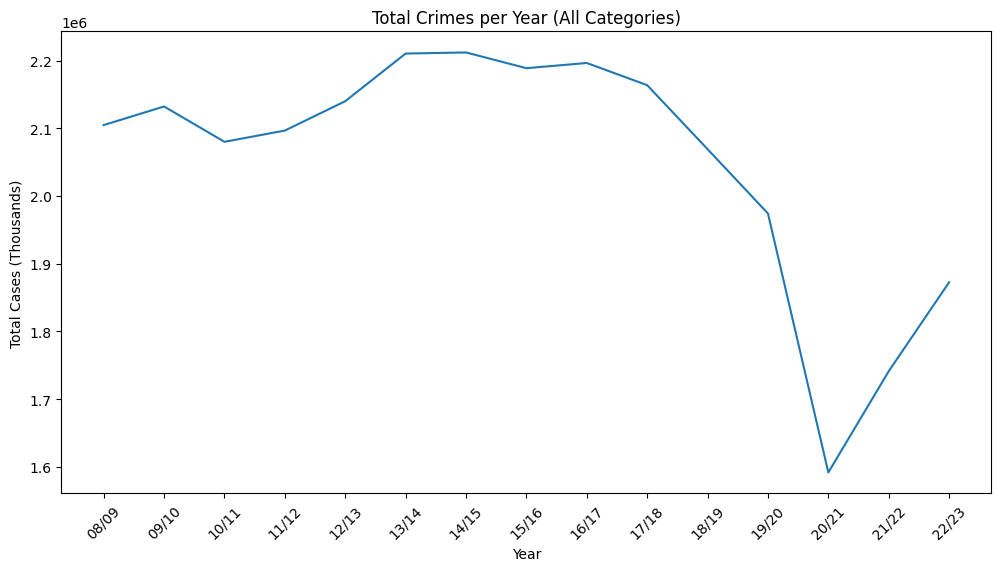

In [153]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=df,
    x='year',
    y='total_cases',
    estimator='sum',
    errorbar=None
)

# Format x-axis labels (2008/2009 → 08/09)
new_labels = [label.get_text()[2:4] + '/' + label.get_text()[7:9] 
              for label in ax.get_xticklabels()]

ax.set_xticklabels(new_labels, rotation=45)

plt.title('Total Crimes per Year (All Categories)')
plt.ylabel('Total Cases (Thousands)')
plt.xlabel('Year')

plt.show()

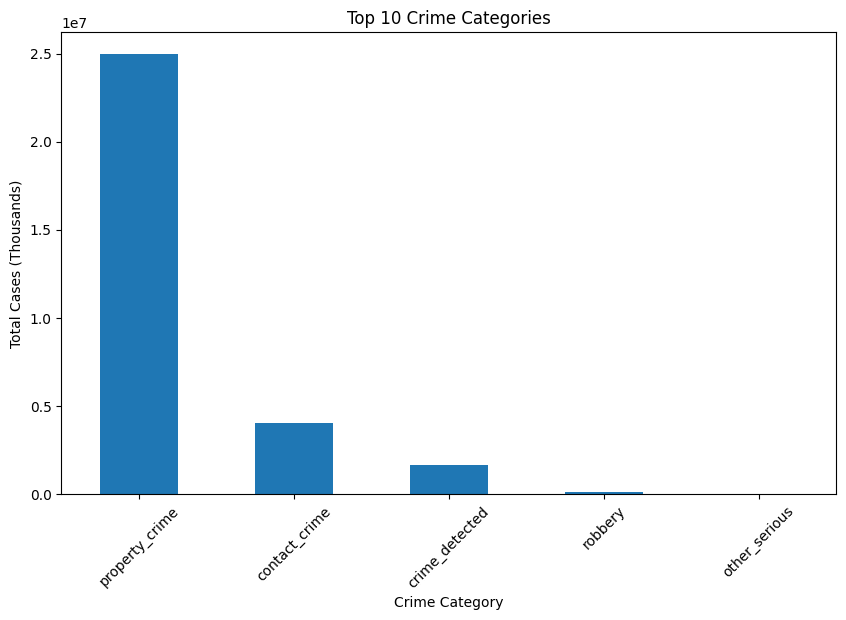

In [154]:
# Top 10 crime categories
top_crimes = df.groupby('crime_category')['total_cases'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_crimes.plot(kind='bar')

plt.title('Top 10 Crime Categories')
plt.ylabel('Total Cases (Thousands)')  
plt.xlabel('Crime Category')          
plt.xticks(rotation=45)

plt.show()

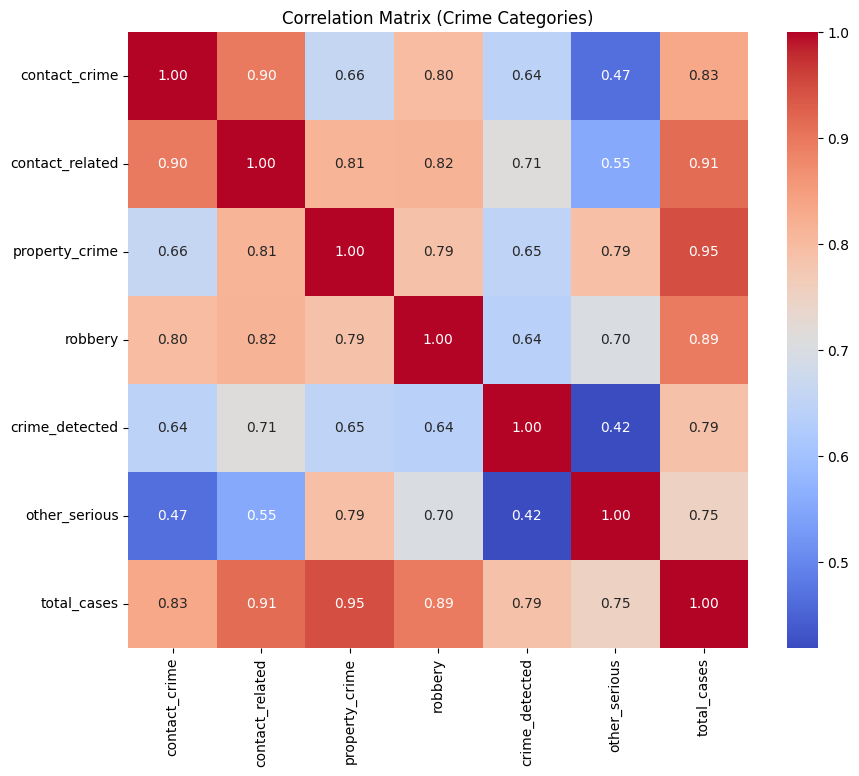

In [155]:
# Select only grouped crime categories
group_cols = [
    'contact_crime',
    'contact_related',
    'property_crime',
    'robbery',
    'crime_detected',
    'other_serious',
    'total_cases'
]

# Correlation matrix
plt.figure(figsize=(10,8))
corr = df[group_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix (Crime Categories)')
plt.show()

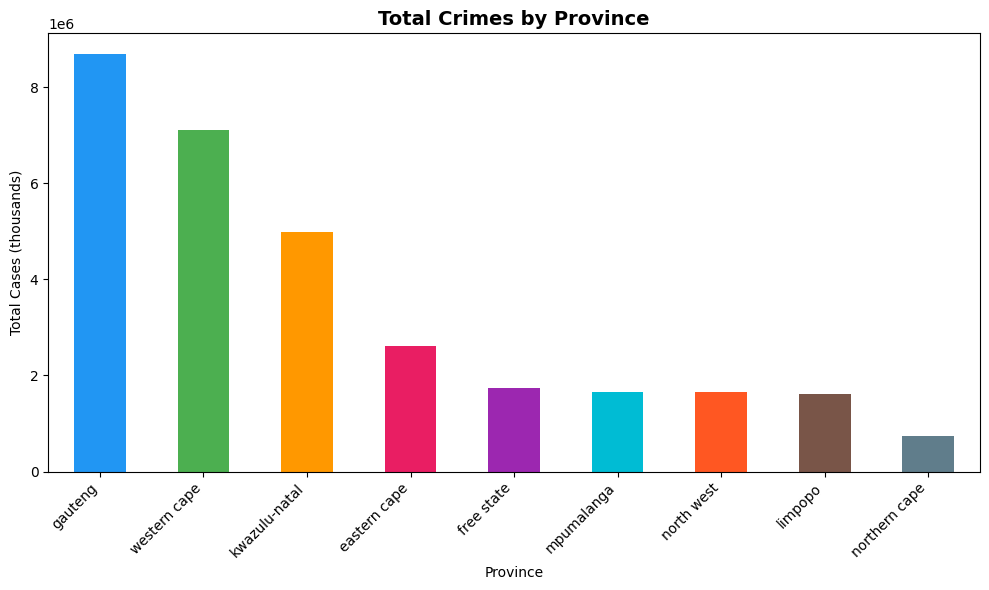

In [156]:
province_mapping = {
    # Gauteng
    'city of johannesburg': 'gauteng',
    'city of tshwane': 'gauteng',
    'ekurhuleni': 'gauteng',
    'emfuleni': 'gauteng',
    'lesedi': 'gauteng',
    'merafong city': 'gauteng',
    'midvaal': 'gauteng',
    'mogale city': 'gauteng',
    'rand west city': 'gauteng',

    # KwaZulu-Natal
    'ethekwini': 'kwazulu-natal',
    'the msunduzi': 'kwazulu-natal',
    'abaqulusi': 'kwazulu-natal',
    'alfred duma': 'kwazulu-natal',
    'big five hlabisa': 'kwazulu-natal',
    'dannhauser': 'kwazulu-natal',
    'dr nkosazana dlamini zuma': 'kwazulu-natal',
    'dr pixley ka isaka seme': 'kwazulu-natal',
    'edumbe': 'kwazulu-natal',
    'emadlangeni': 'kwazulu-natal',
    'endumeni': 'kwazulu-natal',
    'greater kokstad': 'kwazulu-natal',
    'impendle': 'kwazulu-natal',
    'inkosi langalibalele': 'kwazulu-natal',
    'jozini': 'kwazulu-natal',
    'kwadukuza': 'kwazulu-natal',
    'mandeni': 'kwazulu-natal',
    'maphumulo': 'kwazulu-natal',
    'mfolozi': 'kwazulu-natal',
    'mkhambathini': 'kwazulu-natal',
    'mkhondo': 'kwazulu-natal',
    'mpofana': 'kwazulu-natal',
    'msinga': 'kwazulu-natal',
    'mthonjaneni': 'kwazulu-natal',
    'mtubatuba': 'kwazulu-natal',
    'ndwedwe': 'kwazulu-natal',
    'newcastle': 'kwazulu-natal',
    'nkandla': 'kwazulu-natal',
    'nongoma': 'kwazulu-natal',
    'nqutu': 'kwazulu-natal',
    'okhahlamba': 'kwazulu-natal',
    'ray nkonyeni': 'kwazulu-natal',
    'richmond': 'kwazulu-natal',
    'ubuhlebezwe': 'kwazulu-natal',
    'ulundi': 'kwazulu-natal',
    'umdoni': 'kwazulu-natal',
    'umhlabuyalingana': 'kwazulu-natal',
    'umhlathuze': 'kwazulu-natal',
    'umlalazi': 'kwazulu-natal',
    'umngeni': 'kwazulu-natal',
    'umshwathi': 'kwazulu-natal',
    'umuziwabantu': 'kwazulu-natal',
    'umvoti': 'kwazulu-natal',
    'umzimkhulu': 'kwazulu-natal',
    'umzumbe': 'kwazulu-natal',
    'uphongolo': 'kwazulu-natal',

    # Western Cape
    'city of cape town': 'western cape',
    'beaufort west': 'western cape',
    'bergrivier': 'western cape',
    'bitou': 'western cape',
    'breede valley': 'western cape',
    'cape agulhas': 'western cape',
    'cederberg': 'western cape',
    'drakenstein': 'western cape',
    'george': 'western cape',
    'hessequa': 'western cape',
    'kannaland': 'western cape',
    'knysna': 'western cape',
    'kou-kamma': 'western cape',
    'kouga': 'western cape',
    'laingsburg': 'western cape',
    'langeberg': 'western cape',
    'matzikama': 'western cape',
    'mossel bay': 'western cape',
    'oudtshoorn': 'western cape',
    'overstrand': 'western cape',
    'prince albert': 'western cape',
    'saldanha bay': 'western cape',
    'stellenbosch': 'western cape',
    'swartland': 'western cape',
    'swellendam': 'western cape',
    'theewaterskloof': 'western cape',
    'witzenberg': 'western cape',

    # Eastern Cape
    'nelson mandela bay': 'eastern cape',
    'buffalo city': 'eastern cape',
    'amahlathi': 'eastern cape',
    'blue crane route': 'eastern cape',
    'dr beyers naude': 'eastern cape',
    'elundini': 'eastern cape',
    'engcobo': 'eastern cape',
    'enoch mgijima': 'eastern cape',
    'great kei': 'eastern cape',
    'intsika yethu': 'eastern cape',
    'inxuba yethemba': 'eastern cape',
    'king sabata dalindyebo': 'eastern cape',
    'makana': 'eastern cape',
    'matatiele': 'eastern cape',
    'mbhashe': 'eastern cape',
    'mbizana': 'eastern cape',
    'mhlontlo': 'eastern cape',
    'mnquma': 'eastern cape',
    'ndlambe': 'eastern cape',
    'ngqushwa': 'eastern cape',
    'ngquza hill': 'eastern cape',
    'ntabankulu': 'eastern cape',
    'nyandeni': 'eastern cape',
    'port st johns': 'eastern cape',
    'raymond mhlaba': 'eastern cape',
    'sakhisizwe': 'eastern cape',
    'senqu': 'eastern cape',
    'sundays river valley': 'eastern cape',
    'walter sisulu': 'eastern cape',

    # Limpopo
    'ba-phalaborwa': 'limpopo',
    'bela-bela': 'limpopo',
    'blouberg': 'limpopo',
    'collins chabane': 'limpopo',
    'ephraim mogale': 'limpopo',
    'fetakgomo tubatse': 'limpopo',
    'greater giyani': 'limpopo',
    'greater letaba': 'limpopo',
    'greater tzaneen': 'limpopo',
    'lephalale': 'limpopo',
    'lepele-nkumpi': 'limpopo',
    'makhado': 'limpopo',
    'makhuduthamaga': 'limpopo',
    'maruleng': 'limpopo',
    'modimolle-mookgophong': 'limpopo',
    'mogalakwena': 'limpopo',
    'molemole': 'limpopo',
    'musina': 'limpopo',
    'polokwane': 'limpopo',
    'thabazimbi': 'limpopo',
    'thulamela': 'limpopo',

    # Mpumalanga
    'bushbuckridge': 'mpumalanga',
    'chief albert luthuli': 'mpumalanga',
    'city of mbombela': 'mpumalanga',
    'dipaleseng': 'mpumalanga',
    'dr js moroka': 'mpumalanga',
    'elias motsoaledi': 'mpumalanga',
    'emakhazeni': 'mpumalanga',
    'emalahleni': 'mpumalanga',
    'govan mbeki': 'mpumalanga',
    'lekwa': 'mpumalanga',
    'msukaligwa': 'mpumalanga',
    'nkomazi': 'mpumalanga',
    'steve tshwete': 'mpumalanga',
    'thaba chweu': 'mpumalanga',
    'thembisile': 'mpumalanga',
    'victor khanye': 'mpumalanga',

    # North West
    'city of matlosana': 'north west',
    'ditsobotla': 'north west',
    'greater taung': 'north west',
    'jb marks': 'north west',
    'kagisano/molopo': 'north west',
    'kgetlengrivier': 'north west',
    'local municipality of madibeng': 'north west',
    'mafikeng': 'north west',
    'mamusa': 'north west',
    'maquassi hills': 'north west',
    'moretele': 'north west',
    'moses kotane': 'north west',
    'naledi': 'north west',
    'ramotshere moiloa': 'north west',
    'ratlou': 'north west',
    'rustenburg': 'north west',
    'tswaing': 'north west',

    # Free State
    'dihlabeng': 'free state',
    'dikgatlong': 'free state',
    'lekwa-teemane': 'free state',
    'letsemeng': 'free state',
    'mafube': 'free state',
    'maluti a phofung': 'free state',
    'mangaung': 'free state',
    'mantsopa': 'free state',
    'masilonyana': 'free state',
    'matjhabeng': 'free state',
    'metsimaholo': 'free state',
    'mohokare': 'free state',
    'moqhaka': 'free state',
    'nala': 'free state',
    'ngwathe': 'free state',
    'nketoana': 'free state',
    'phumelela': 'free state',
    'setsoto': 'free state',
    'tokologo': 'free state',
    'tswelopele': 'free state',

    # Northern Cape
    '!kheis': 'northern cape',
    'dawid kruiper': 'northern cape',
    'emthanjeni': 'northern cape',
    'ga-segonyana': 'northern cape',
    'hantam': 'northern cape',
    'joe morolong': 'northern cape',
    'kai !garib': 'northern cape',
    'kamiesberg': 'northern cape',
    'kareeberg': 'northern cape',
    'karoo hoogland': 'northern cape',
    'kgatelopele': 'northern cape',
    'khâi-ma': 'northern cape',
    'kopanong': 'northern cape',
    'magareng': 'northern cape',
    'nama khoi': 'northern cape',
    'phokwane': 'northern cape',
    'renosterberg': 'northern cape',
    'richtersveld': 'northern cape',
    'siyancuma': 'northern cape',
    'siyathemba': 'northern cape',
    'sol plaatje': 'northern cape',
    'thembelihle': 'northern cape',
    'tsantsabane': 'northern cape',
    'ubuntu': 'northern cape',
    'umsobomvu': 'northern cape',
}

df['provinces'] = df['loc_mn'].str.lower().map(province_mapping)

province_crimes = df.groupby('provinces')['total_cases'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
province_crimes.plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4','#FF5722','#795548','#607D8B'])
plt.title('Total Crimes by Province', fontsize=14, fontweight='bold')
plt.ylabel('Total Cases (thousands)')
plt.xlabel('Province')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()